<a href="https://colab.research.google.com/github/ImJustToha/lab1_2_im/blob/main/Lab1vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import random
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Conv2D, Dense, MaxPooling2D
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

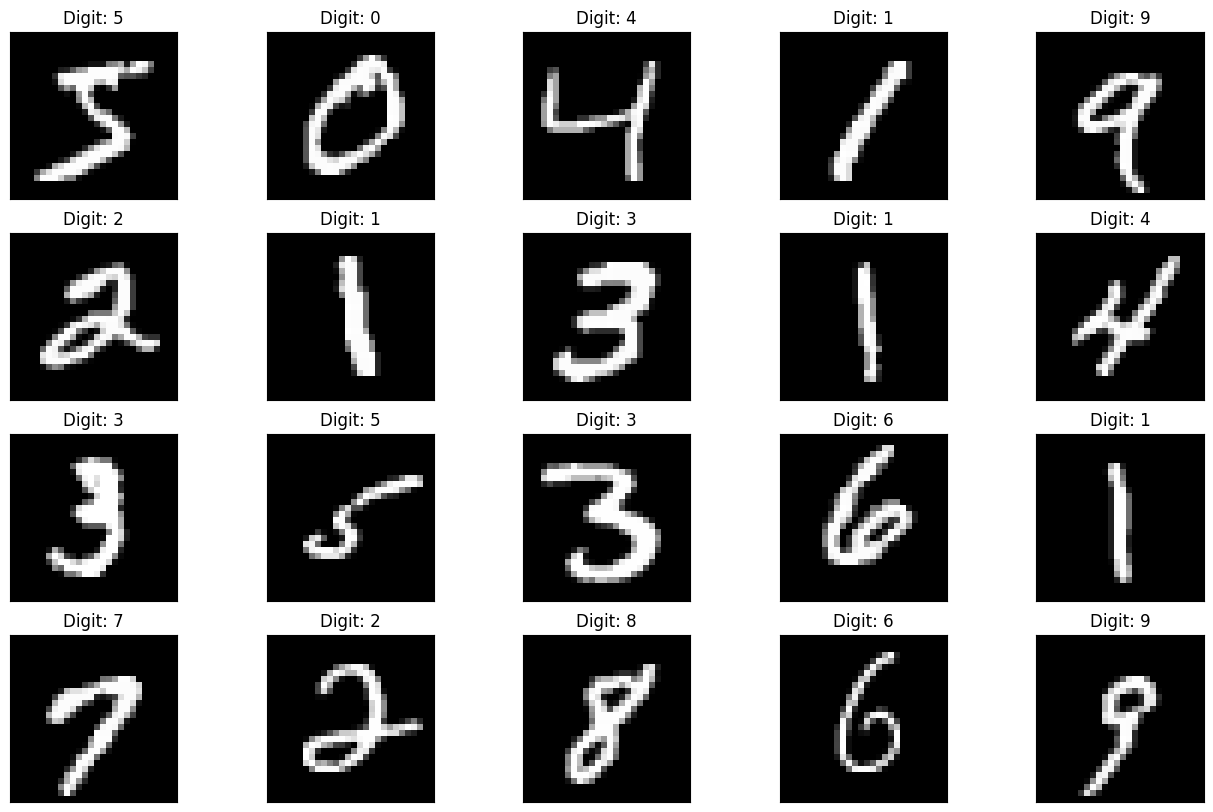

In [ ]:
def plot_digit(image, digit, plt, i):
    plt.subplot(4, 5, i + 1)
    plt.imshow(image, cmap=plt.get_cmap('gray'))
    plt.title(f"Digit: {digit}")
    plt.xticks([])
    plt.yticks([])

plt.figure(figsize=(16, 10))
for i in range(20):
    plot_digit(X_train[i], y_train[i], plt, i)

plt.show()

In [ ]:
X_train = X_train.reshape((X_train.shape + (1,)))
X_test = X_test.reshape((X_test.shape + (1,)))

In [ ]:
model = Sequential([
    Conv2D(32, (5, 5), activation="relu", strides=(1, 1),padding="same", input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2), strides = (2, 2)),
    Conv2D(64, (5, 5), activation = "relu", strides = (1,1), padding = "same"),
    MaxPooling2D((2, 2), strides = (2, 2)),
    Flatten(),
    Dense(512, activation="relu"),
    Dense(10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
optimizer = SGD(learning_rate=0.01, weight_decay= 0.001)
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,606,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,663,370 (6.35 MB)

 Trainable params: 1,663,370 (6.35 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(X_train, y_train, epochs=40, batch_size=64)

Epoch 1/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 100s 106ms/step - accuracy: 0.6552 - loss: 1.2592
Epoch 2/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 141s 105ms/step - accuracy: 0.9397 - loss: 0.2024
Epoch 3/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 144s 107ms/step - accuracy: 0.9629 - loss: 0.1268
Epoch 4/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 140s 105ms/step - accuracy: 0.9703 - loss: 0.0999
Epoch 5/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 96s 102ms/step - accuracy: 0.9773 - loss: 0.0791
Epoch 6/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 143s 104ms/step - accuracy: 0.9794 - loss: 0.0704
Epoch 7/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 140s 102ms/step - accuracy: 0.9823 - loss: 0.0606
Epoch 8/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 144s 104ms/step - accuracy: 0.9827 - loss: 0.0567
Epoch 9/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 143s 106ms/step - accuracy: 0.9846 - loss: 0.0511
Epoch 10/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 100s 107ms/step - accuracy: 0.9870 - loss: 0.0452
Epoch 11/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 140s 105ms/step - accuracy: 0.9871 - loss: 0.0439
Epoch 12/

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


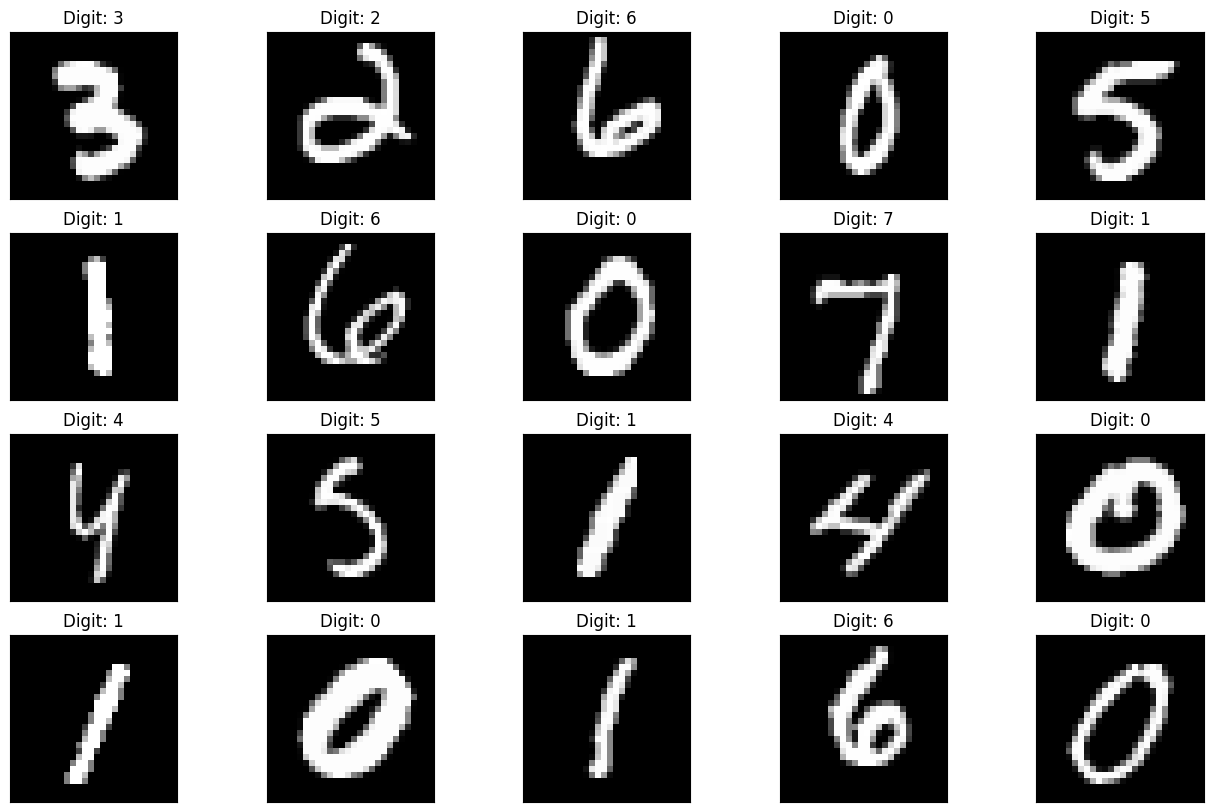

In [ ]:
model.save("digit_model.keras")
plt.figure(figsize=(16, 10))
for i in range(20):
    image = random.choice(X_test).squeeze()
    digit = np.argmax(model.predict(image.reshape((1, 28, 28, 1)))[0], axis=-1)
    plot_digit(image, digit, plt, i)

plt.show()

In [ ]:
predictions = np.argmax(model.predict(X_test), axis=-1)
accuracy_score(y_test, predictions)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


0.9906

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


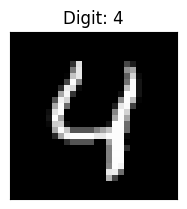

In [ ]:

plt.figure(figsize=(16, 10))
image = (X_test[4]).squeeze()
digit = np.argmax(model.predict(image.reshape((1, 28, 28, 1)))[0], axis=-1)
plot_digit(image, digit, plt, 1)
plt.show()

In [ ]:
print(model.predict(image.reshape((1, 28, 28, 1)))[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
[7.7671253e-08 1.1287179e-06 9.3199979e-08 5.4023719e-08 9.9960357e-01
 7.8073432e-09 5.5189184e-07 1.1995789e-06 4.6413422e-08 3.9329025e-04]


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate
from skimage.restoration import denoise_tv_chambolle

def recognize_digit(image_path, model):
    print(f"\nProcessing: {image_path}")
    original = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if original is None: raise ValueError("Image not found")

    original_inv = 255 - original
    resized = cv2.resize(original_inv, (28, 28), interpolation=cv2.INTER_AREA)
    normalized = resized.astype(np.float32) / 255.0

    gamma = 2.5
    pre_processed = np.power(normalized, gamma)
    denoised = denoise_tv_chambolle(pre_processed, weight=0.02)

    denoised[denoised < 0.15] = 0
    denoised[denoised > 0.25] = 1

    best_digit, best_conf, best_probs, best_image, best_angle = None, -1, None, None, 0
    angles = list(range(-90, 90, 5))
    conf_history, digit_history = [], []

    for angle in angles:
        rotated = rotate(denoised, angle, reshape=False, order = 0)
        input_img = rotated.reshape(1, 28, 28, 1)

        probs = model.predict(input_img, verbose=0)[0]
        digit = np.argmax(probs)
        conf = np.max(probs)

        conf_history.append(conf)
        digit_history.append(digit)

        if conf > best_conf:
            best_conf, best_digit, best_probs, best_image, best_angle = conf, digit, probs, rotated, angle


    fig = plt.figure(figsize=(15, 14))


    plt.subplot(3, 3, 1)
    plt.imshow(original_inv, cmap="gray"); plt.title("Inverted"); plt.axis("off")

    plt.subplot(3, 3, 2)
    plt.imshow(resized, cmap="gray"); plt.title("Resized 28x28"); plt.axis("off")

    plt.subplot(3, 3, 3)
    plt.imshow(denoised, cmap="gray"); plt.title("After Gamma & ROF"); plt.axis("off")


    plt.subplot(3, 1, 2)
    plt.plot(angles, conf_history, color='tab:blue', linewidth=2, marker='o')


    for i, digit_label in enumerate(digit_history):
        plt.text(angles[i], conf_history[i] + 0.02, str(digit_label),
                 ha='center', va='bottom', fontsize=11, fontweight='bold',
                 color='red' if digit_label == best_digit else 'black')

    plt.axvline(x=best_angle, color='green', linestyle='--', alpha=0.5)
    plt.title("Впевненість та передбачена цифра для кожного кута")
    plt.xlabel("Кут повороту")
    plt.ylabel("Впевненість")
    plt.ylim(0, 1.1)
    plt.grid(True, linestyle=':', alpha=0.6)


    plt.subplot(3, 3, 7)
    plt.imshow(best_image, cmap="gray")
    plt.title(f"Best: {best_angle}°")
    plt.axis("off")

    plt.subplot(3, 3, (8, 9))
    plt.bar(range(10), best_probs, color='skyblue')
    plt.xticks(range(10))
    plt.ylim(0, 1)
    plt.title(f"Ймовірності (Цифра: {best_digit})")

    plt.subplots_adjust(hspace=0.6, wspace=0.3)

    plt.show()

    return best_digit, best_probs


Processing: photo_1.jpg


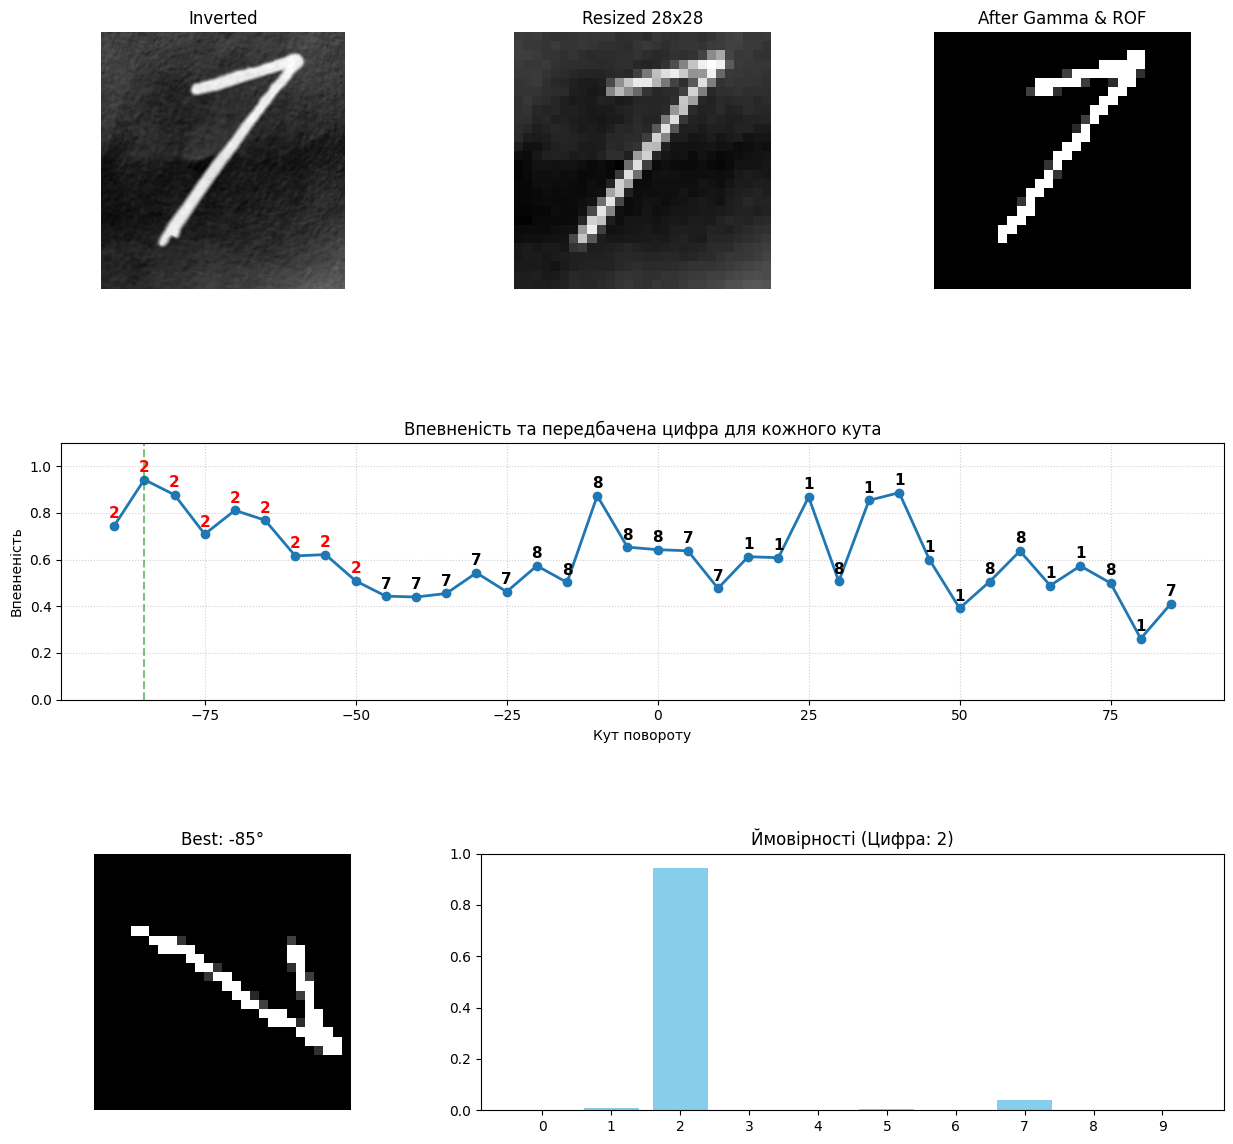


Processing: photo_2.jpg


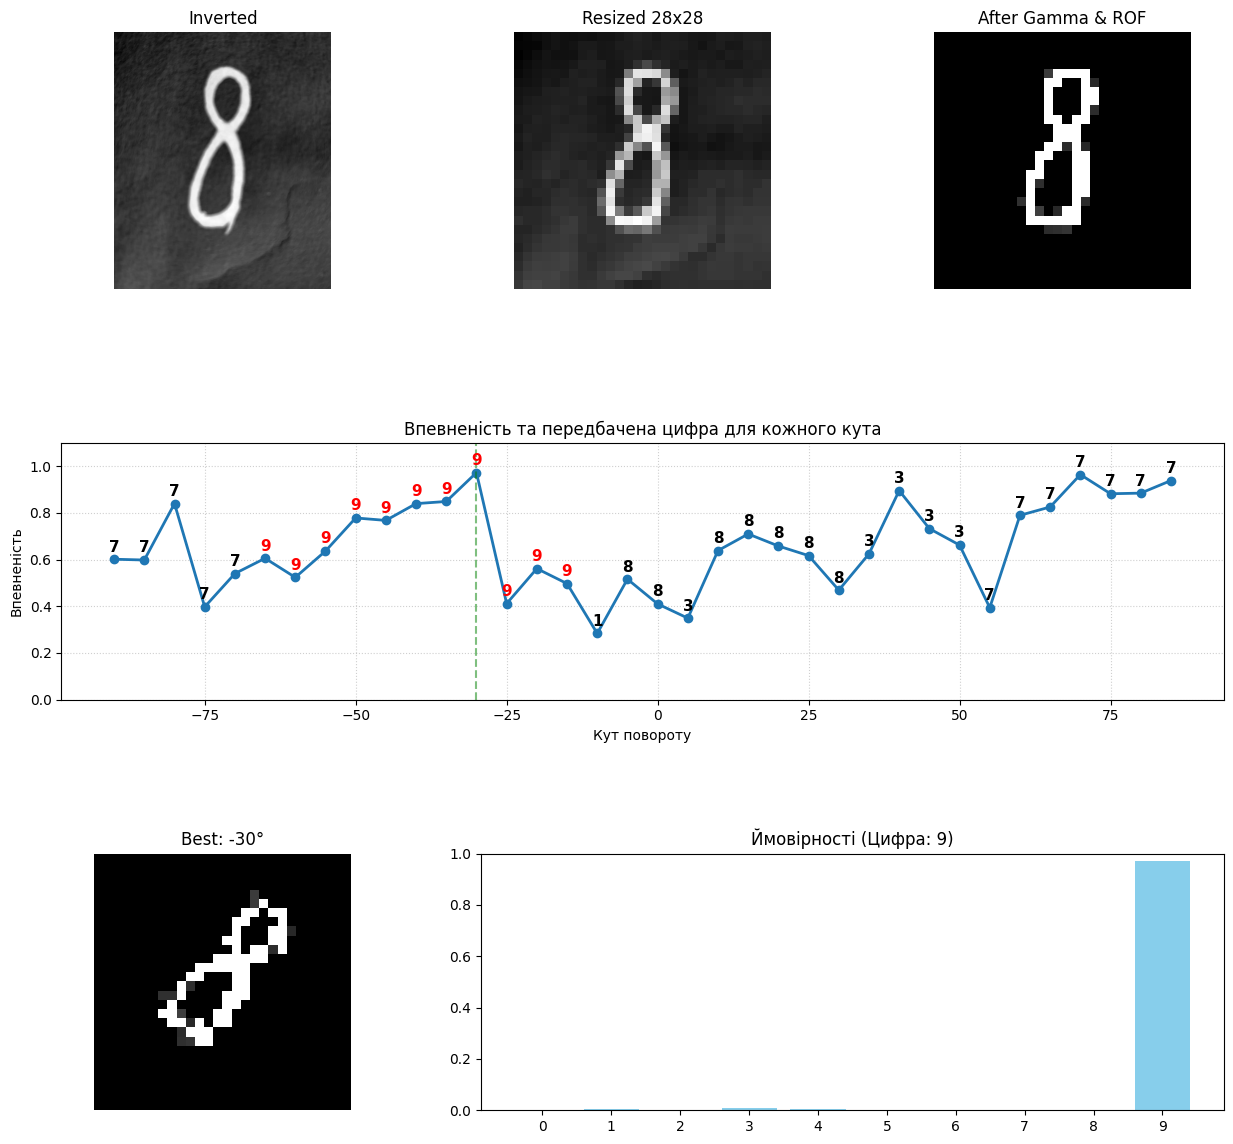


Processing: photo_3.jpg


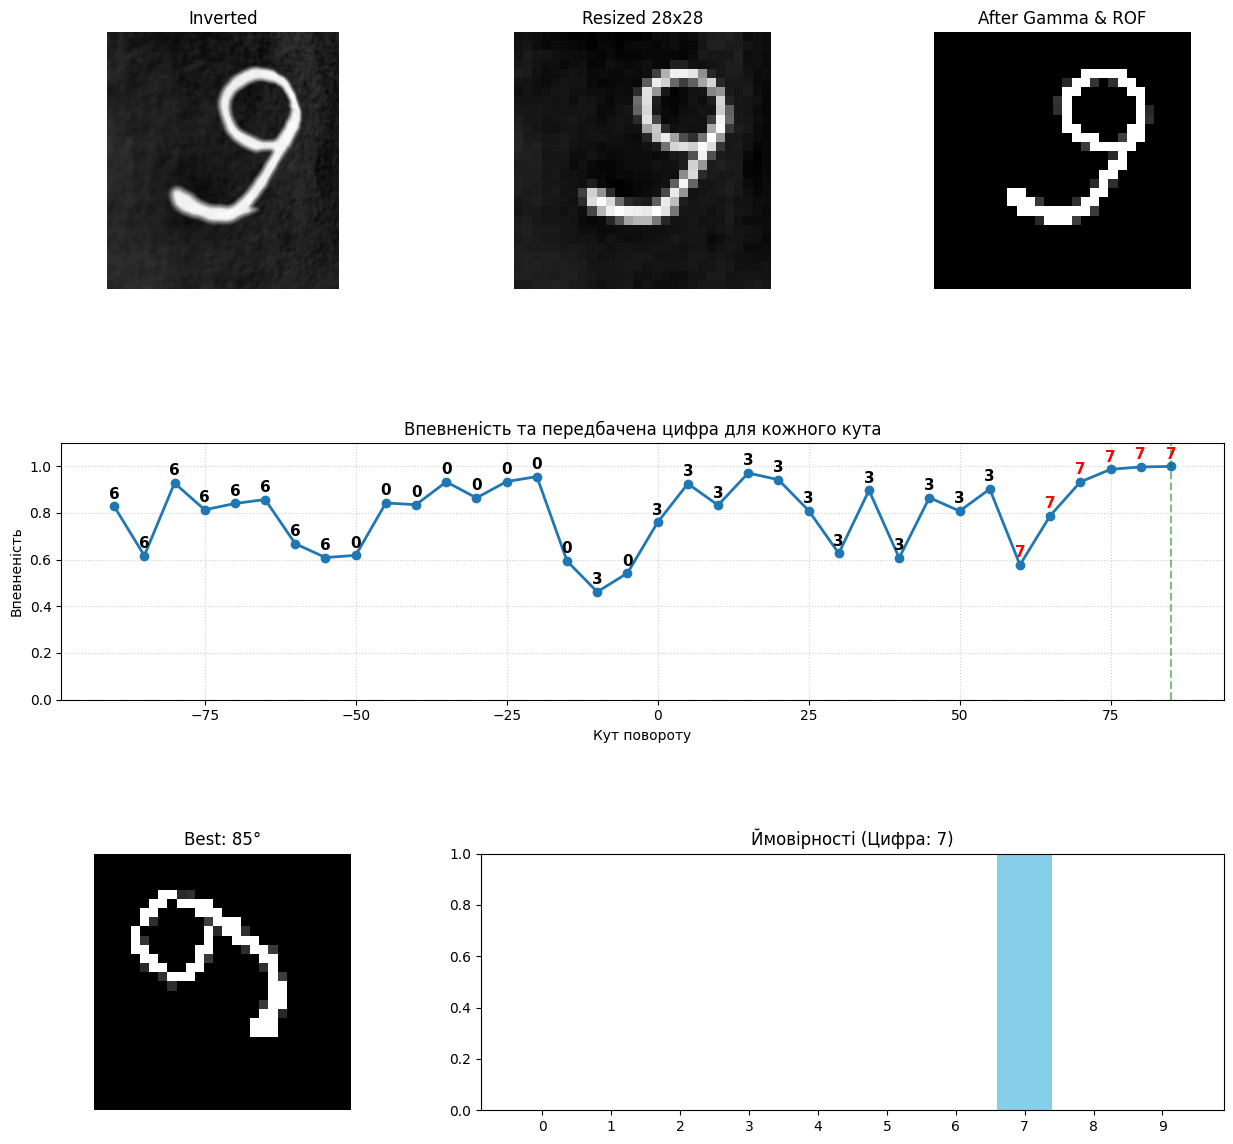


Processing: photo_4.jpg


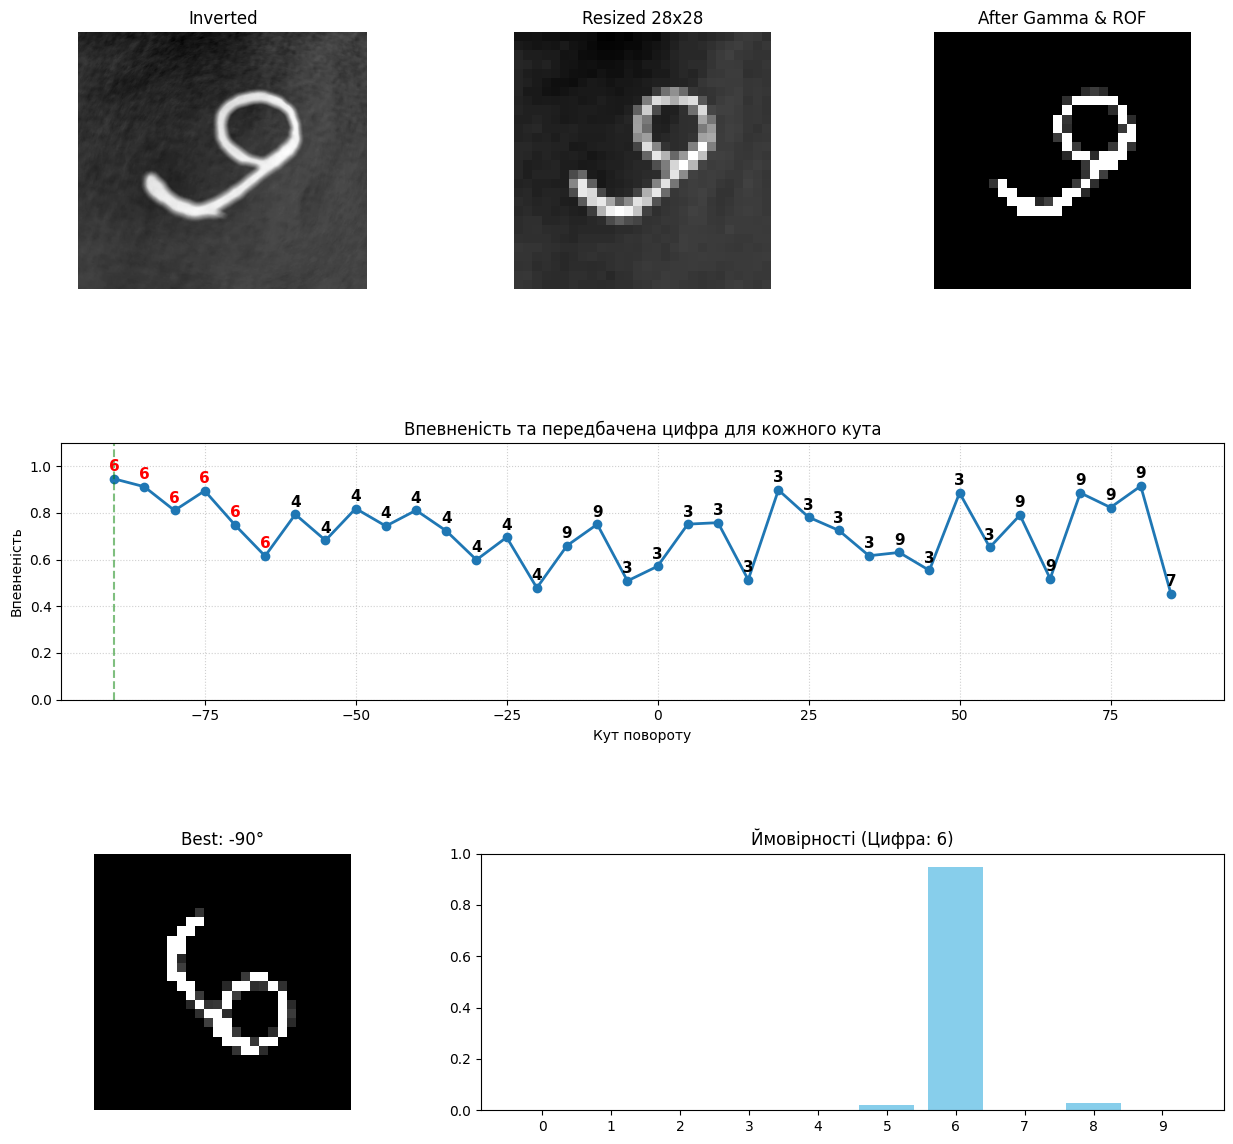


Processing: photo_5.jpg


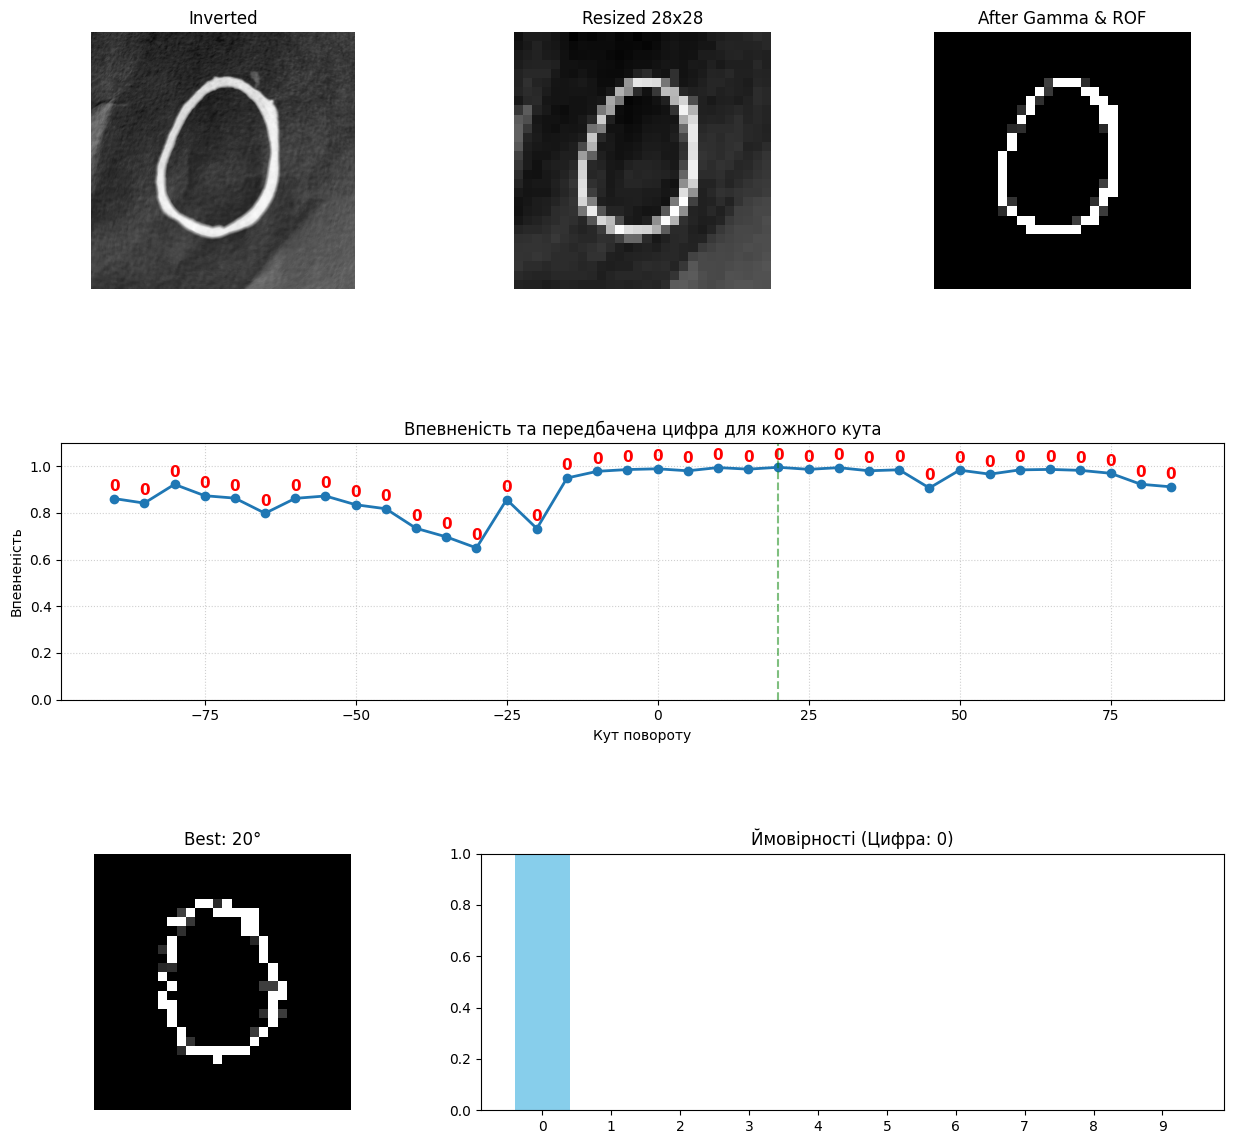


Processing: photo_6.jpg


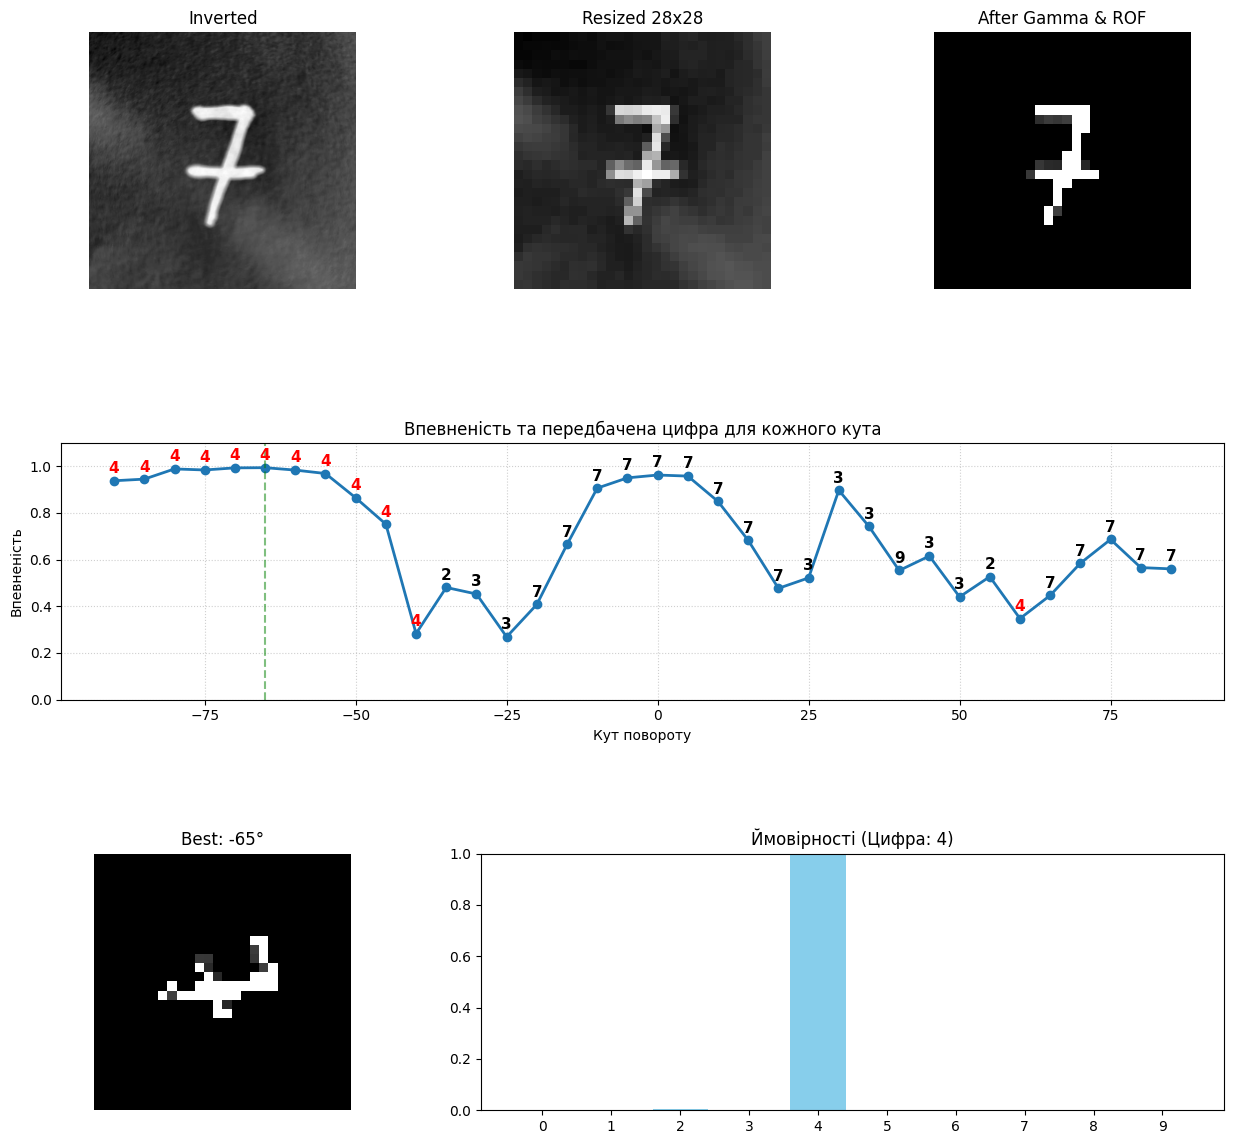


Processing: photo_7.jpg


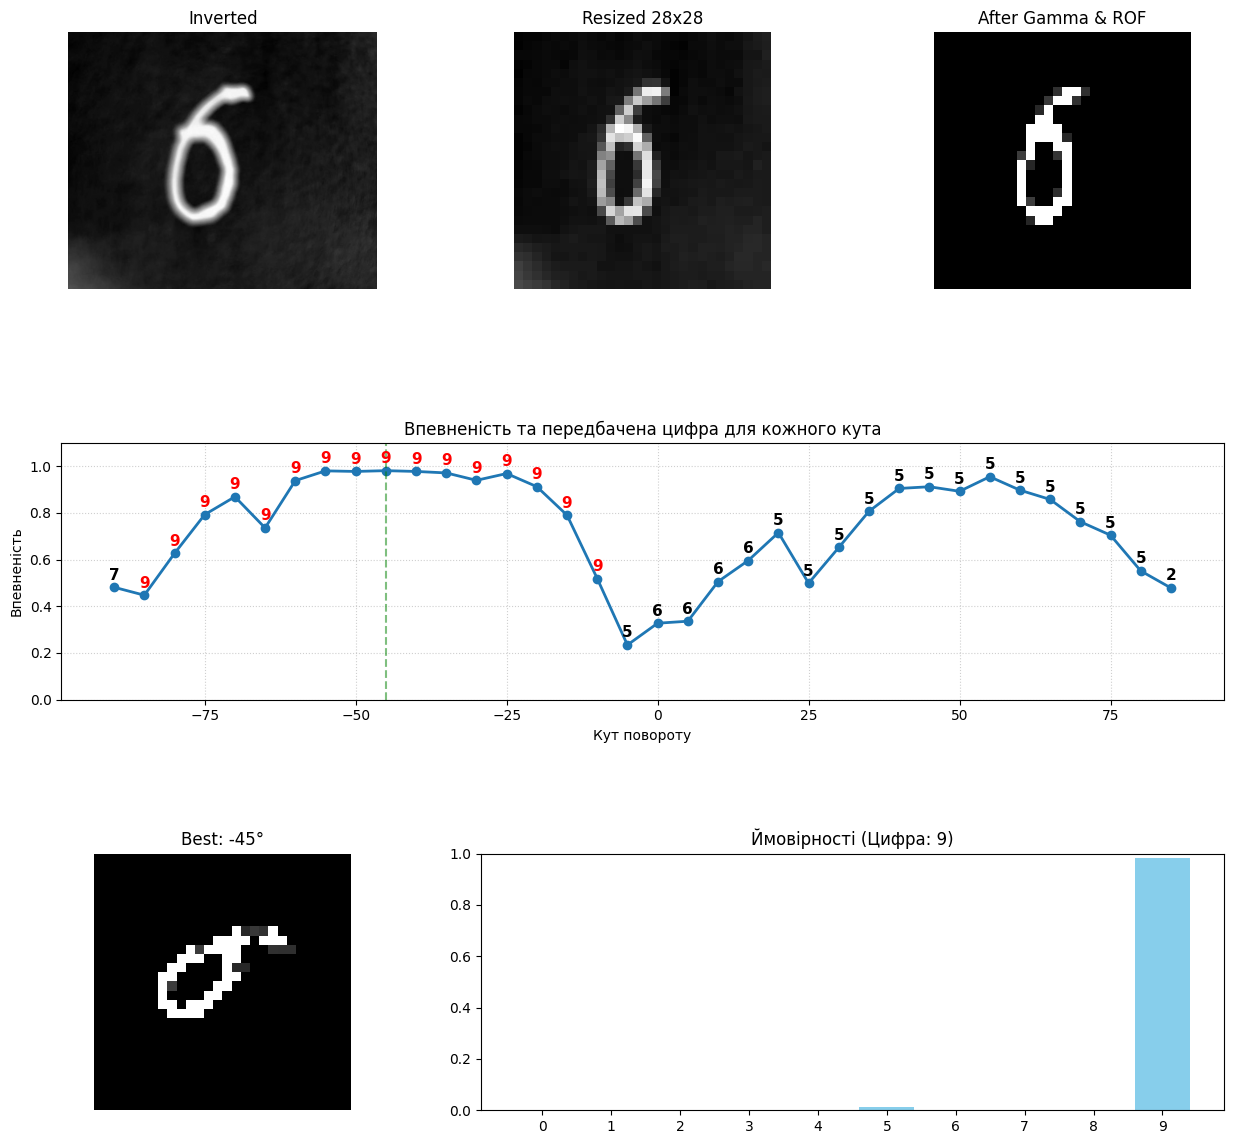


Processing: photo_8.jpg


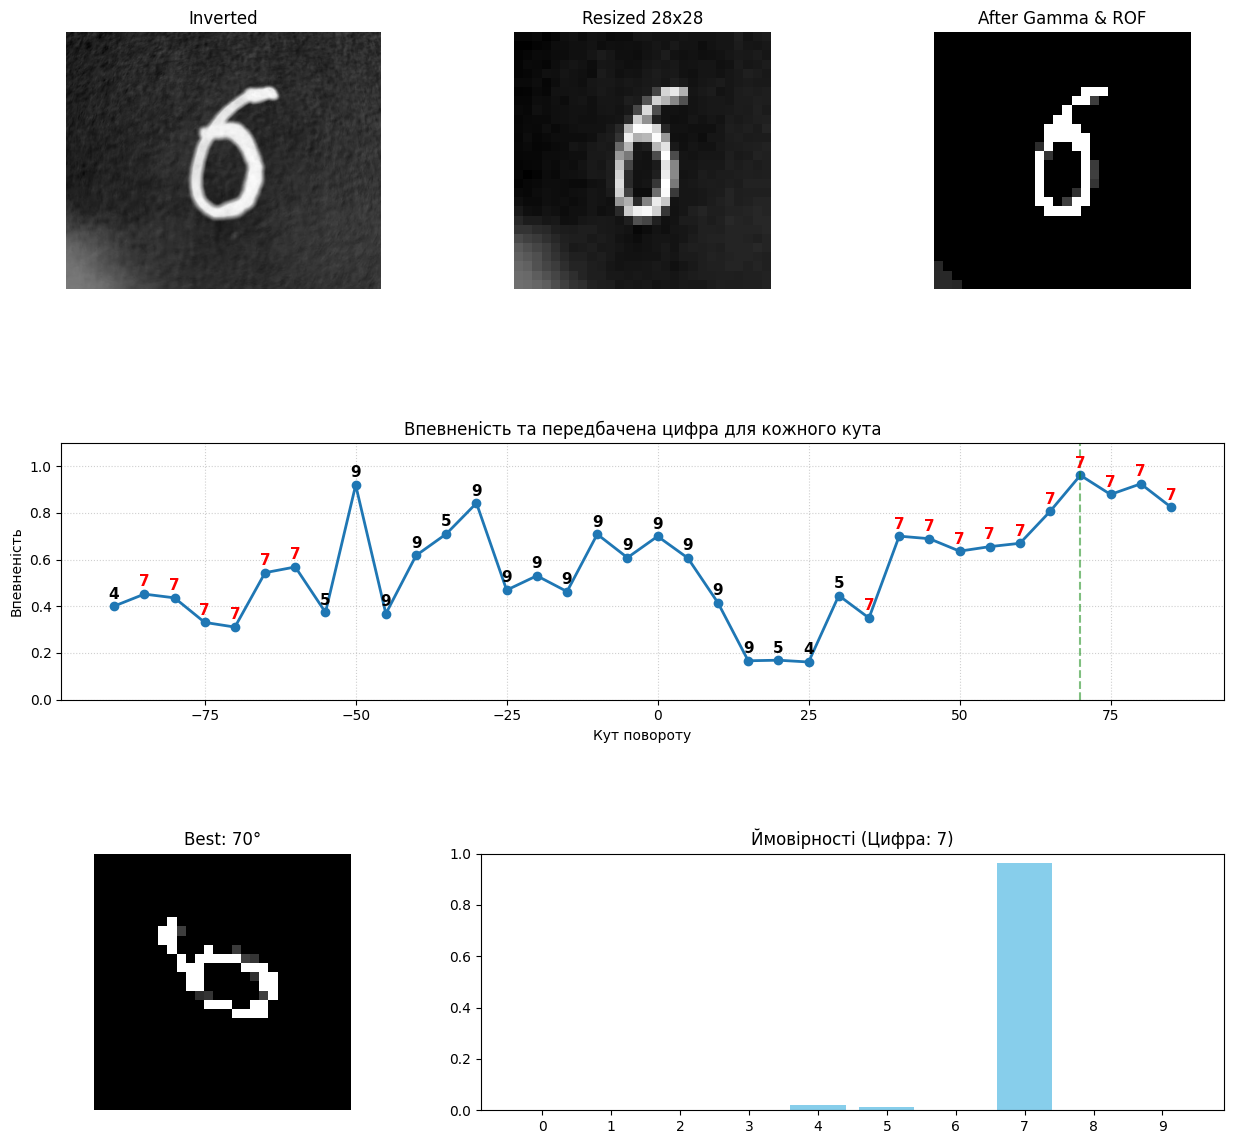


Processing: photo_9.jpg


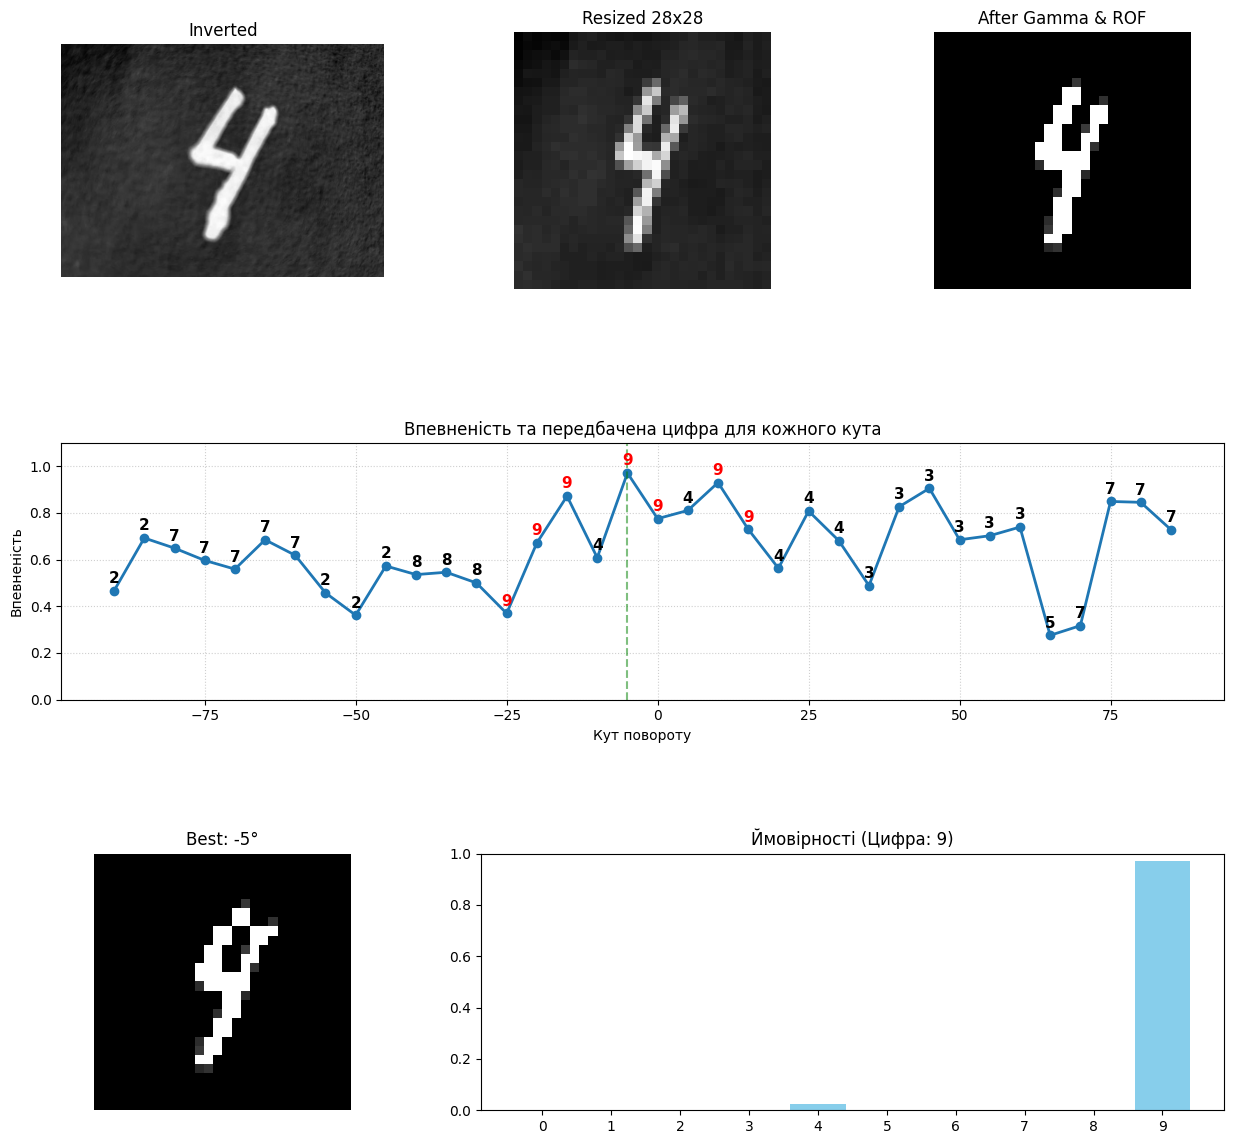


Processing: photo_10.jpg


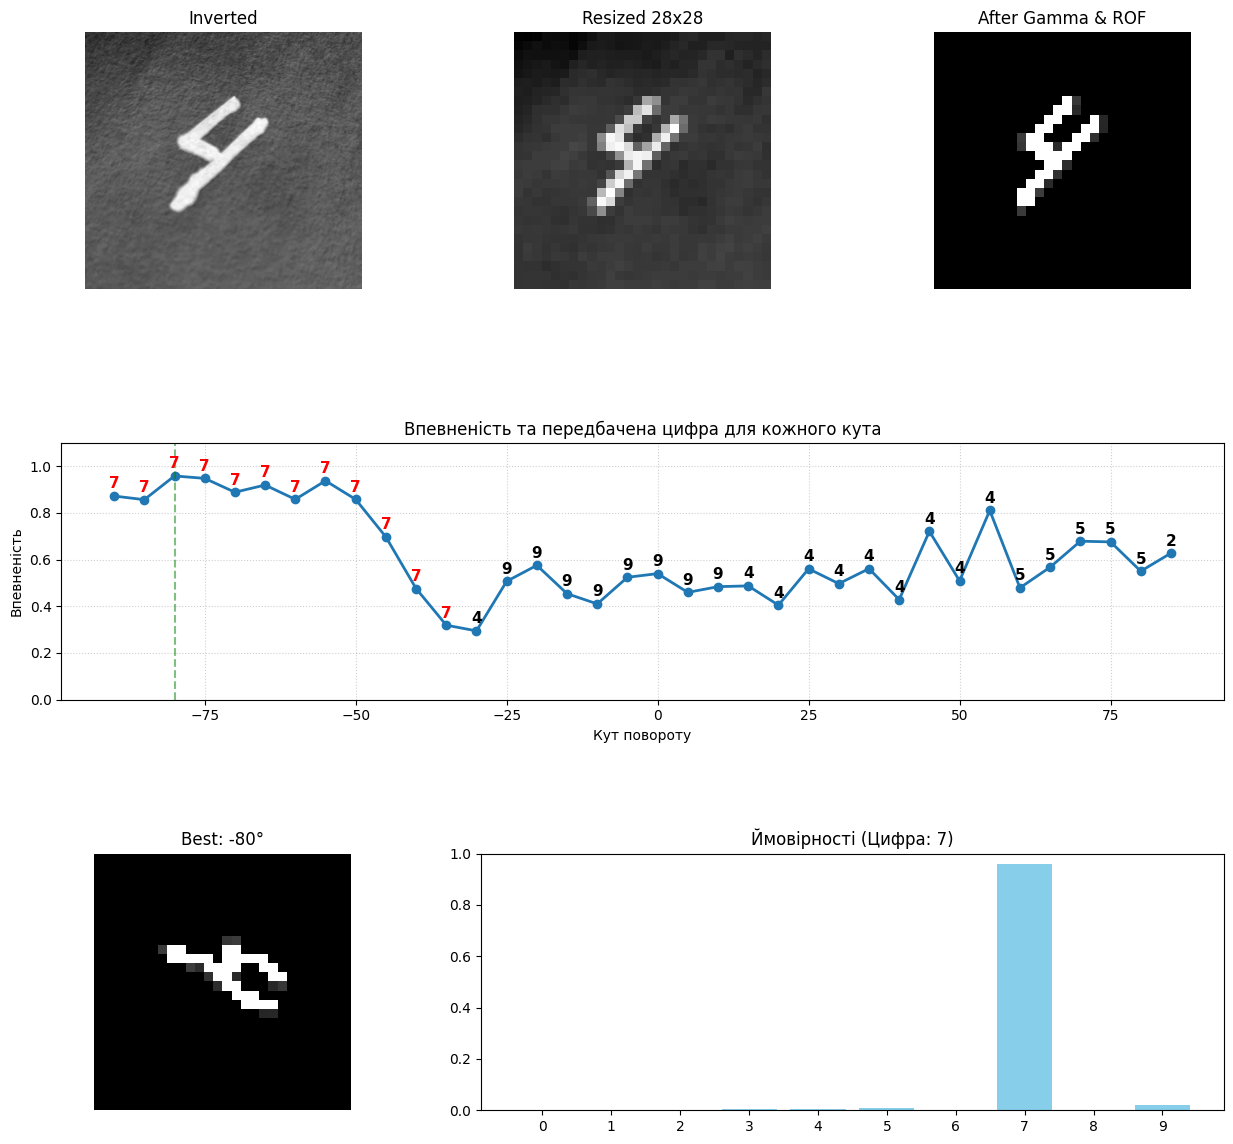


Processing: photo_11.jpg


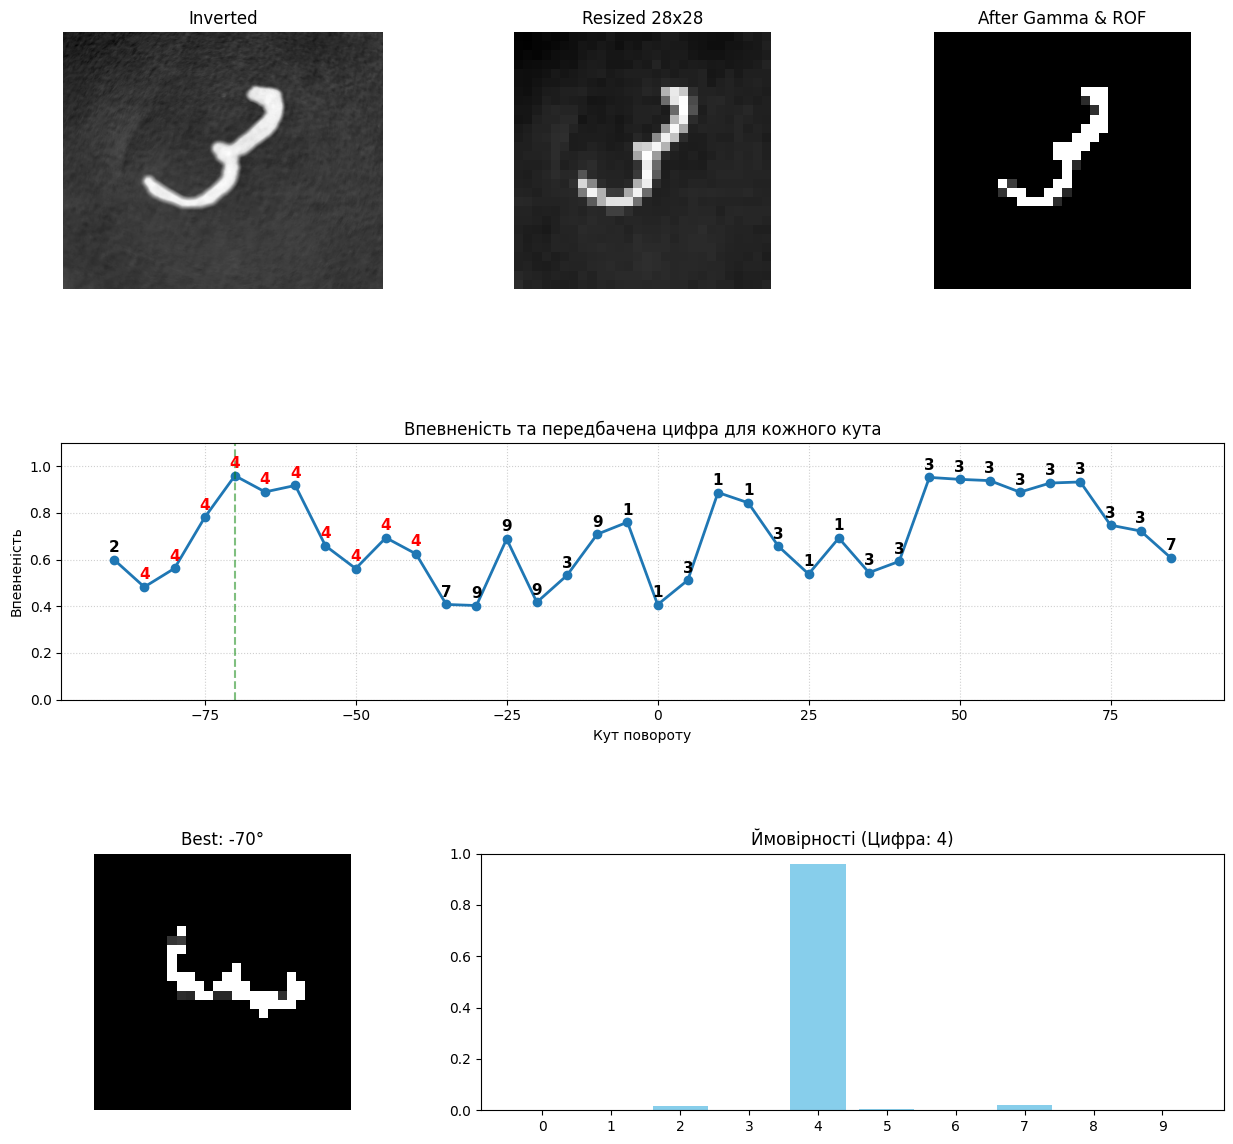


Processing: photo_12.jpg


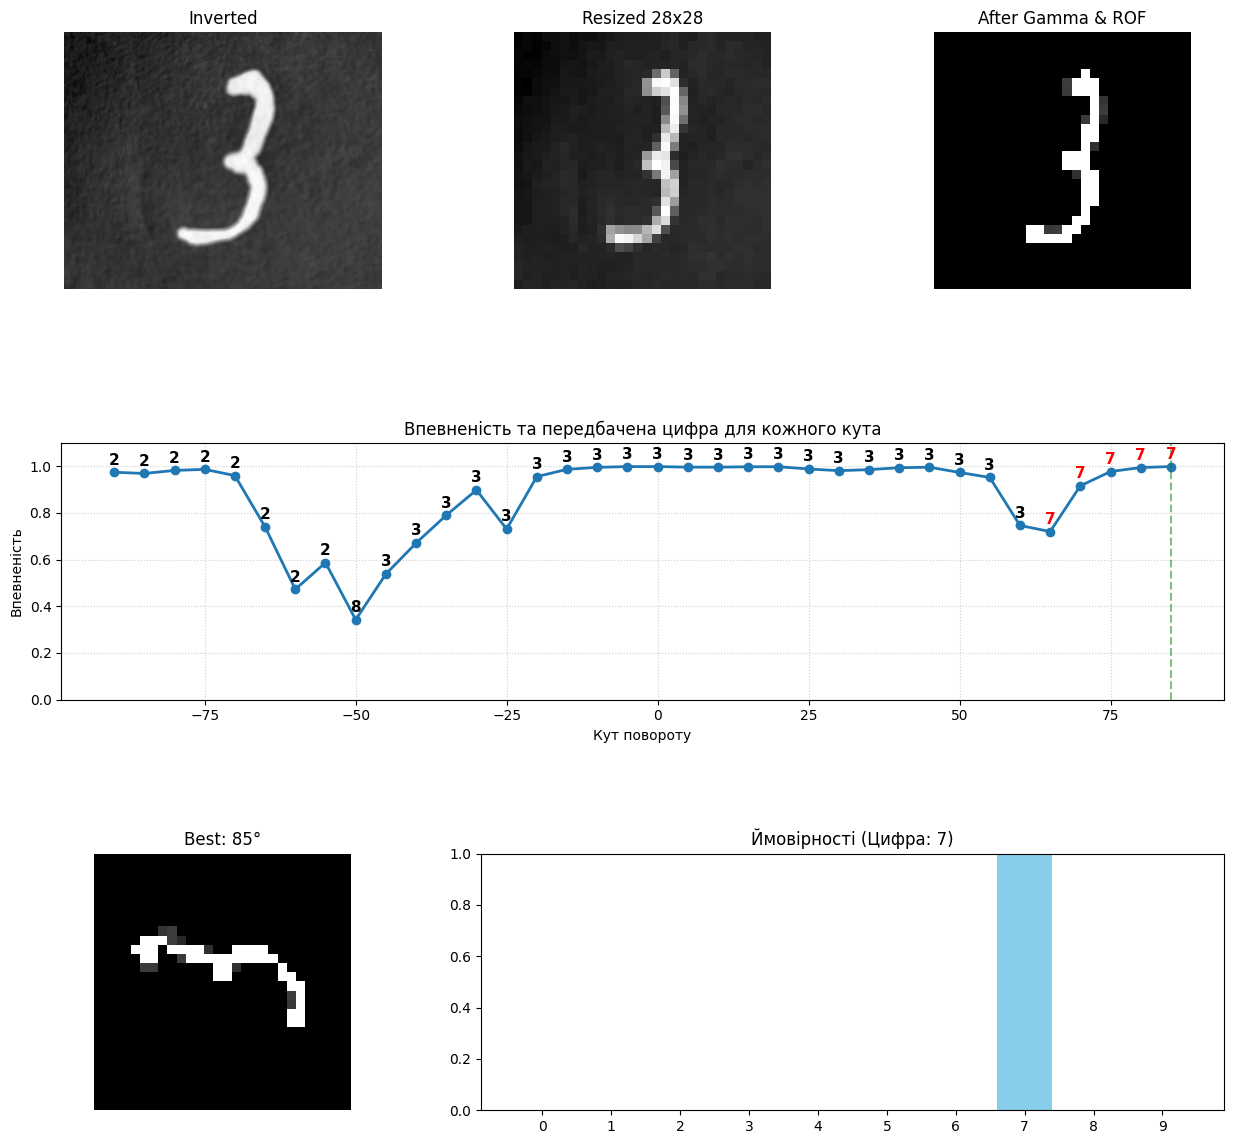


Processing: photo_13.jpg


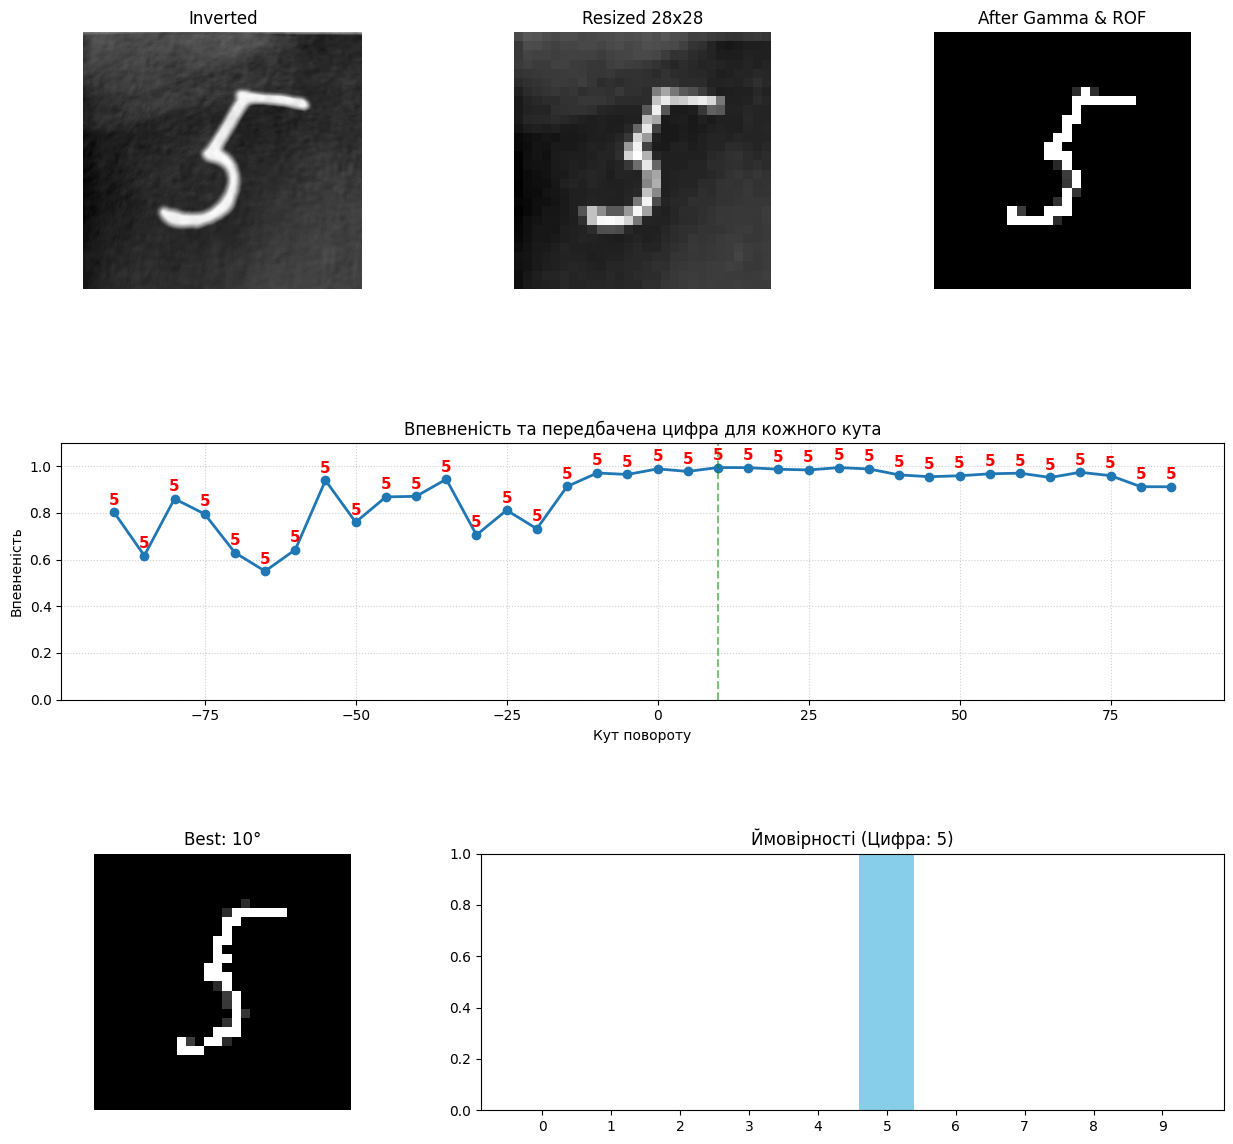


Processing: photo_14.jpg


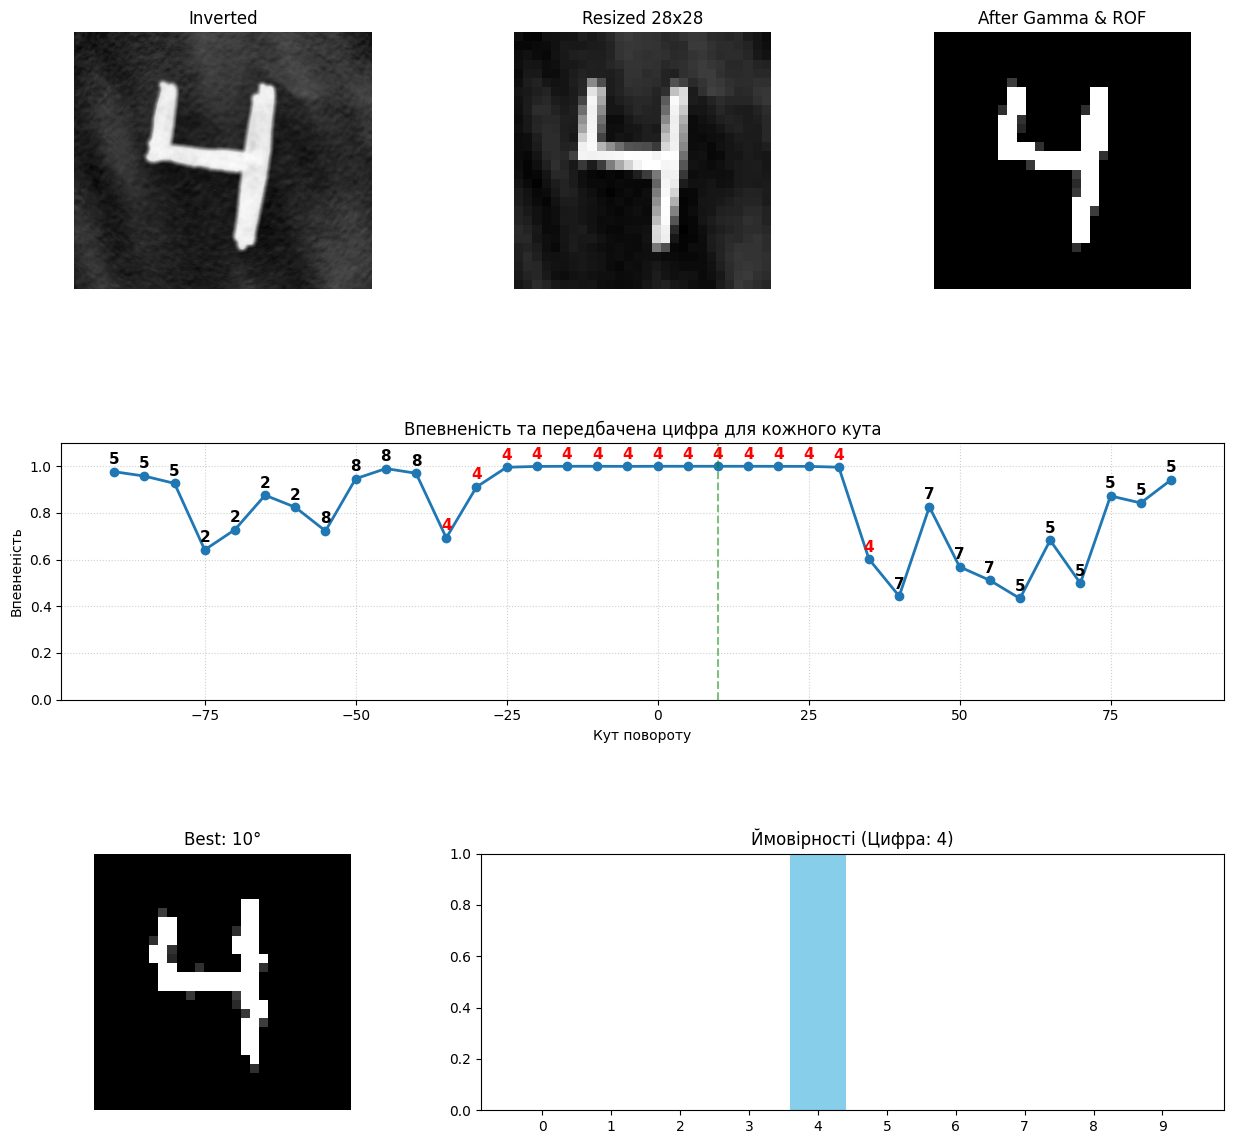

In [ ]:
image_paths = [
    "photo_1.jpg",
    "photo_2.jpg",
    "photo_3.jpg",
    "photo_4.jpg",
    "photo_5.jpg",
    "photo_6.jpg",
    "photo_7.jpg",
    "photo_8.jpg",
    "photo_9.jpg",
    "photo_10.jpg",
    "photo_11.jpg",
    "photo_12.jpg",
    "photo_13.jpg",
    "photo_14.jpg",
]

for path in image_paths:

    recognize_digit(path, model)